In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드  
> vworld의 중개사 + 피터팬 크롤링 크롤링 중개사 매칭한 데이터

In [2]:
# 데이터 로드
clean_path = "../../../../data/seoul_broker_clean.csv"
df = pd.read_csv(clean_path)

print("="*50)
print("데이터 기본 정보")
print("="*50)
print(f"\n데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n기본 통계:\n{df.describe()}")
print(f"\n결측치 정보:\n{df.isnull().sum()}")
df.head()

데이터 기본 정보

데이터 크기: 380행 x 13열

컬럼 목록:
['jurirno', 'brkrNm', 'ldCodeNm', 'registDe', 'mnnmadr', 'estbsBeginDe', 'estbsEndDe', 'sttusSeCode', 'bsnmCmpnm', '등록번호', '거래완료', '등록매물', '총매물수']

데이터 타입:
jurirno         object
brkrNm          object
ldCodeNm        object
registDe        object
mnnmadr         object
estbsBeginDe    object
estbsEndDe      object
sttusSeCode      int64
bsnmCmpnm       object
등록번호            object
거래완료             int64
등록매물             int64
총매물수             int64
dtype: object

기본 통계:
       sttusSeCode           거래완료        등록매물           총매물수
count        380.0     380.000000  380.000000     380.000000
mean           1.0    8003.092105   50.065789    8053.157895
std            0.0   35495.157061   77.796625   35543.811252
min            1.0       0.000000    0.000000       0.000000
25%            1.0      24.000000   10.000000      47.500000
50%            1.0     358.000000   21.000000     389.500000
75%            1.0    2310.000000   58.250000    2374.7500

,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,거래완료,등록매물,총매물수
0,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,2530,100,2630
1,11620-2024-00006,박지애,서울특별시 관악구,2024-01-10,서울특별시 관악구 신림동 476-11,2025-01-12,2026-01-11,1,The태양공인중개사사무소,11620-2024-00006,950,45,995
2,가3622-05-168,김미정,서울특별시 광진구,2005-10-25,서울특별시 광진구 구의동 254-30,2025-07-22,2026-07-21,1,재테크부동산공인중개사사무소,가3622-05-168,224,10,234
3,11470-2022-00111,하임리나,서울특별시 양천구,2022-11-18,서울특별시 양천구 신월동 341-1,2025-11-21,2026-11-20,1,평강부동산공인중개사사무소,11470-2022-00111,1536,28,1564
4,11590-2015-00090,정종원,서울특별시 관악구,2015-06-18,서울특별시 관악구 봉천동 893-12,2025-06-18,2026-06-17,1,부동산포커스공인중개사사무소,11590201500090,99,30,129


In [3]:
df_origin = df.copy() # 원본
df_eda = df.copy() # eda 쓸 df
df = df.copy() # 전처리 및 feature 생성할 df

> **컬럼**  
>
>    - jurirno: 등록번호  
>    - brkrNm: 중개사 이름  
>    - ldCodeNm: 지역명 (구 단위)  
>    - registDe: 영업시작 일자  
>    - mnnmadr: 소재지  
>    - estbsBeginDe: 보증보험 시작일  
>    - estbsEndDe: 보증보험 종료일  
>    - sttusSeCode: 상태코드 (1: 정상영업중)  
>    - bsnmCmpnm: 중개사무소 상호명  
>    - 등록번호: 중개사 등록번호 (jurirno와 동일)  
>    - 거래완료: 지금까지 거래 완료한 매물 수  
>    - 등록매물: 현재 등록되어있는 매물 수  
>    - 총매물수: 거래완료 + 등록매물  



# EDA_v1

## 기본 통계 & 분포 확인

수치형 컬럼: ['sttusSeCode', '거래완료', '등록매물', '총매물수']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_12168\1121013118.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


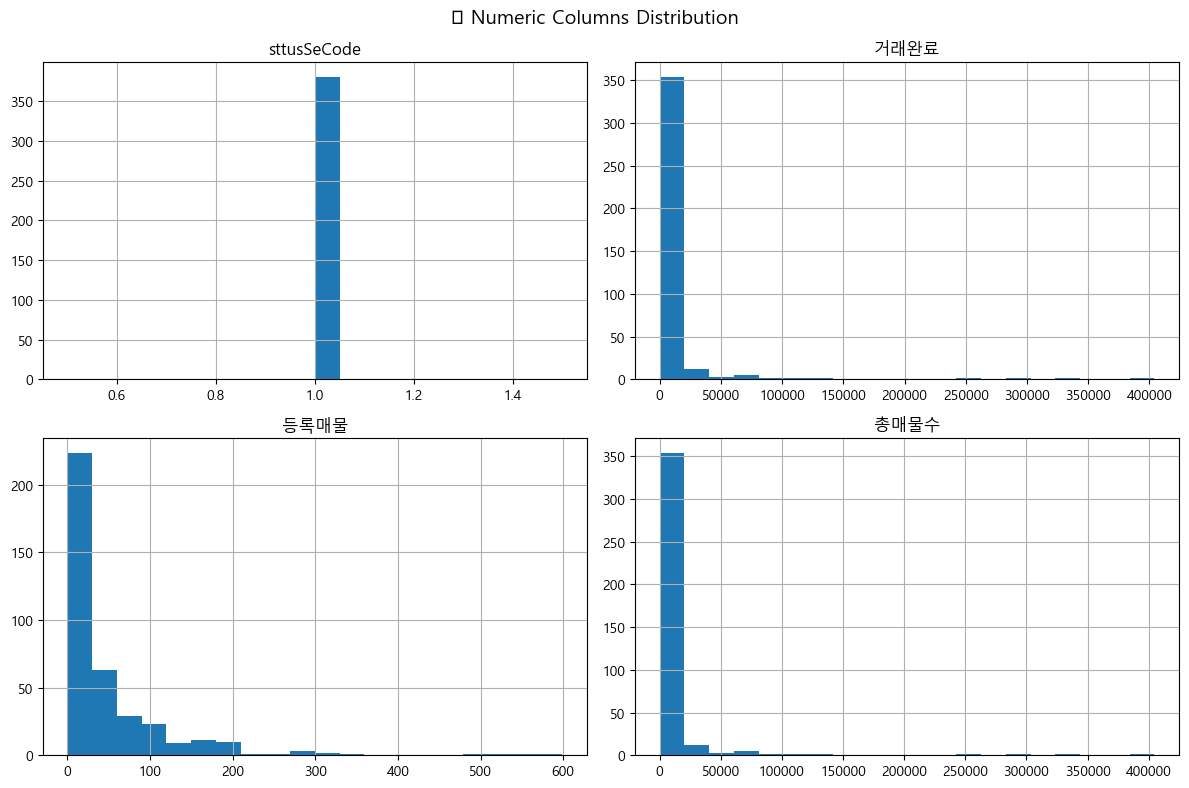


 describe(include='all') 결과


,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,거래완료,등록매물,총매물수
count,380,380,380,380,380,380,380,380.0,380,380,380.000000,380.000000,380.000000
unique,380,377,25,343,372,237,237,NaN,346,370,NaN,NaN,NaN
top,11620-2021-00004,이선우,서울특별시 관악구,2023-04-17,서울특별시 강남구 역삼동 825-20,2025-01-03,2026-01-02,NaN,바른공인중개사사무소,11650-2022-00036,NaN,NaN,NaN
freq,1,2,69,3,3,7,7,NaN,4,3,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,8003.092105,50.065789,8053.157895
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,35495.157061,77.796625,35543.811252
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,24.000000,10.000000,47.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,358.000000,21.000000,389.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2310.000000,58.250000,2374.750000


In [4]:
# 전체 히스토그램 (수치형 컬럼만)
numeric_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns
print(f"수치형 컬럼: {numeric_cols.tolist()}")

df_eda[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("📊 Numeric Columns Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# 요약통계
print("\n describe(include='all') 결과")
display(df_eda.describe(include='all'))


## 거래 성사율(success_rate) 분석


📈 success_rate 기본 통계
count    380.000000
mean       0.741578
std        0.353438
min        0.000000
25%        0.615385
50%        0.934496
75%        0.985430
max        0.999279
Name: success_rate, dtype: float64


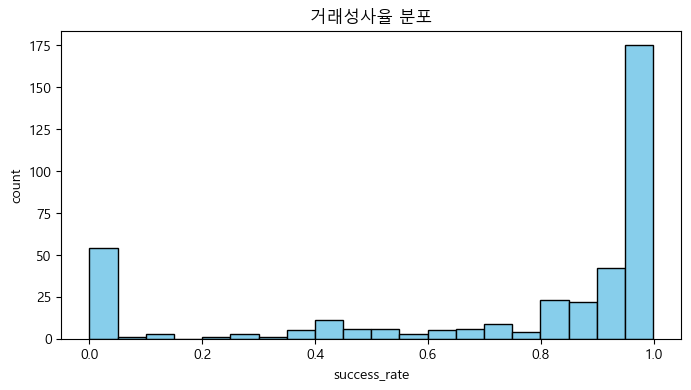


 <지역별 평균> success_rate


ldCodeNm
서울특별시 중구      0.939781
서울특별시 동작구     0.908646
서울특별시 은평구     0.885635
서울특별시 마포구     0.870775
서울특별시 구로구     0.844063
서울특별시 강서구     0.840004
서울특별시 광진구     0.791734
서울특별시 영등포구    0.770932
서울특별시 강북구     0.766481
서울특별시 금천구     0.764891
서울특별시 관악구     0.745829
서울특별시 양천구     0.726223
서울특별시 성동구     0.725003
서울특별시 중랑구     0.713144
서울특별시 강남구     0.707181
서울특별시 용산구     0.701647
서울특별시 동대문구    0.692532
서울특별시 송파구     0.648791
서울특별시 서초구     0.640290
서울특별시 서대문구    0.636005
서울특별시 성북구     0.596471
서울특별시 강동구     0.487714
서울특별시 종로구     0.400000
서울특별시 노원구     0.332547
서울특별시 도봉구     0.332046
Name: success_rate, dtype: float64

In [5]:
# success_rate(거래 성사율) 파생 변수 생성
df_eda["success_rate"] = df_eda["거래완료"] / (df_eda["총매물수"] + 1e-6)  # 0 나누기 방지

print("\n📈 success_rate 기본 통계")
print(df_eda["success_rate"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df_eda["success_rate"], bins=20, color='skyblue', edgecolor='black')
plt.title("거래성사율 분포")
plt.xlabel("success_rate")
plt.ylabel("count")
plt.show()

# 지역별 평균 성사율
print("\n <지역별 평균> success_rate")
region_success = df_eda.groupby("ldCodeNm")["success_rate"].mean().sort_values(ascending=False)
display(region_success)


## 보증보험 분석

In [6]:
# 보증보험 유효 여부 확인

# 날짜 변환
df_eda["estbsBeginDe"] = pd.to_datetime(df_eda["estbsBeginDe"], errors='coerce')
df_eda["estbsEndDe"] = pd.to_datetime(df_eda["estbsEndDe"], errors='coerce')

# 거래성사율 생성 (없으면)
if '거래성사율' not in df_eda.columns:
    df_eda['거래성사율'] = df_eda['거래완료'] / (df_eda['총매물수'] + 1)

# 보증보험 유효 여부
today = pd.Timestamp.today()
df_eda["보증보험유효"] = (df_eda["estbsEndDe"] >= today).astype(int)

print(f"유효: {df_eda['보증보험유효'].sum()}개")
print(f"만료: {(df_eda['보증보험유효'] == 0).sum()}개")

# 만료된 중개사 전체 정보
expired = df_eda[df_eda['보증보험유효'] == 0]

if len(expired) > 0:
    print(f"\n보증보험 만료 중개사 ({len(expired)}개):\n")
    
    for idx, row in expired.iterrows():
        print(f"{'='*60}")
        print(f"중개사: {row['brkrNm']} ({row['bsnmCmpnm']})")
        print(f"지역: {row['ldCodeNm']}")
        print(f"보험만료: {row['estbsEndDe'].strftime('%Y-%m-%d')}")
        print(f"거래완료: {row['거래완료']}건 / 총매물: {row['총매물수']}건")
        print(f"거래성사율: {row['거래성사율']:.1%}")
        print()


유효: 377개
만료: 3개

보증보험 만료 중개사 (3개):

중개사: 김도원 (또또부동산공인중개사사무소)
지역: 서울특별시 동작구
보험만료: 2025-12-01
거래완료: 1819건 / 총매물: 1858건
거래성사율: 97.8%

중개사: 김지아 (삼성공인중개사사무소)
지역: 서울특별시 강북구
보험만료: 2025-11-28
거래완료: 584건 / 총매물: 605건
거래성사율: 96.4%

중개사: 천승우 (SD공인중개사사무소)
지역: 서울특별시 서초구
보험만료: 2025-12-03
거래완료: 0건 / 총매물: 20건
거래성사율: 0.0%



## 개업일(registDe) 분석


📈 years_active 기본 통계
count    380.000000
mean       5.455263
std        6.244415
min        0.000000
25%        1.000000
50%        4.000000
75%        7.000000
max       41.000000
Name: years_active, dtype: float64


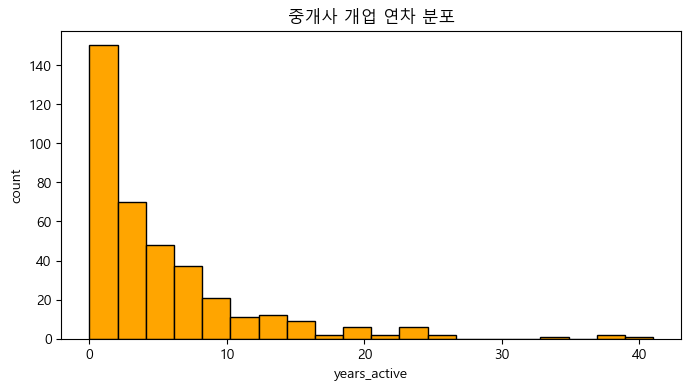

In [7]:
# 날짜로 변환
df_eda["registDe"] = pd.to_datetime(df_eda["registDe"], errors='coerce')

# 활동 연차 계산
df_eda["years_active"] = pd.Timestamp.today().year - df_eda["registDe"].dt.year

print("\n📈 years_active 기본 통계")
print(df_eda["years_active"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df_eda["years_active"], bins=20, color='orange', edgecolor='black')
plt.title("중개사 개업 연차 분포")
plt.xlabel("years_active")
plt.ylabel("count")
plt.show()


## 컬럼 간 상관관계 분석

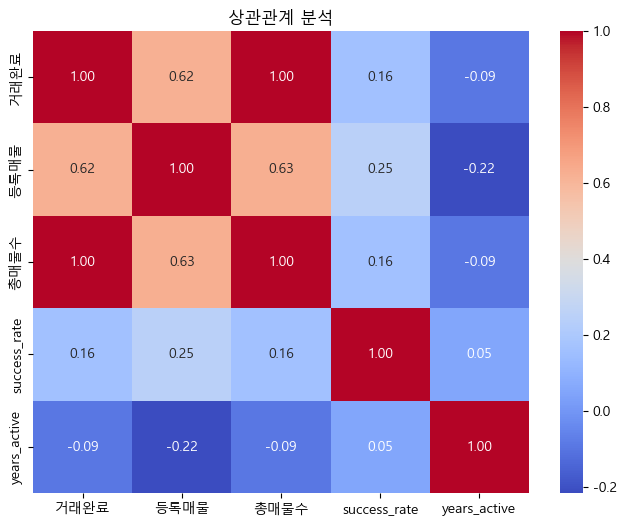

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[["거래완료","등록매물","총매물수","success_rate","years_active"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계 분석")
plt.show()


## 지역별 분석

In [9]:
# 1. 지역별 기본 통계

if '거래성사율' not in df_eda.columns:
    df_eda['거래성사율'] = df_eda['거래완료'] / (df_eda['총매물수'] + 1)

region_stats = df_eda.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래완료': ['mean', 'median', 'sum'],
    '총매물수': ['mean', 'median'],
    '거래성사율': ['mean', 'median']
}).round(2)

region_stats.columns = ['중개사수', '평균거래', '중앙거래', '총거래', '평균매물', '중앙매물', '평균성사율', '중앙성사율']
region_stats = region_stats.sort_values('평균성사율', ascending=False)

print("="*70)
print("지역별 통계")
print("="*70)
print(region_stats)

지역별 통계
            중개사수      평균거래   중앙거래      총거래      평균매물    중앙매물  평균성사율  중앙성사율
ldCodeNm                                                                  
서울특별시 중구       3    238.00  234.0      714    248.33   244.0   0.93   0.96
서울특별시 동작구     15   6821.20  988.0   102318   6887.00  1082.0   0.90   0.96
서울특별시 은평구     11   6890.55  168.0    75796   6915.73   186.0   0.88   0.90
서울특별시 마포구     14  33797.21  576.0   473161  33861.79   599.0   0.86   0.96
서울특별시 구로구      7   2139.57  874.0    14977   2194.14   990.0   0.84   0.96
서울특별시 강서구     32   7493.91  603.0   239805   7538.03   624.5   0.83   0.96
서울특별시 광진구     26   1080.50  286.0    28093   1105.88   293.0   0.79   0.94
서울특별시 영등포구    10   1880.30  933.5    18803   1916.00  1013.5   0.77   0.97
서울특별시 금천구     21  17257.86  810.0   362415  17328.95   845.0   0.76   0.96
서울특별시 강북구      7   2350.71  584.0    16455   2376.71   605.0   0.76   0.96
서울특별시 관악구     69  15736.74  816.0  1085835  15813.28   856.0   0.74   0.94
서울특별시 성동구      7  

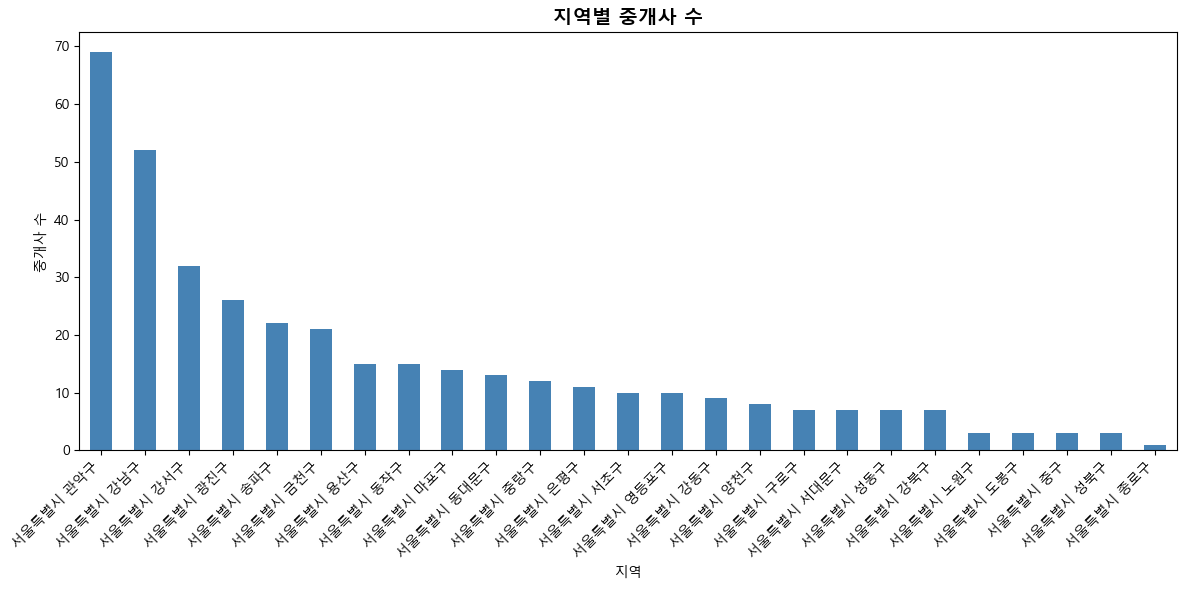

In [10]:
# 2. 시각화 - 지역별 중개사 수
plt.figure(figsize=(12, 6))
region_counts = df_eda['ldCodeNm'].value_counts()
region_counts.plot(kind='bar', color='steelblue')
plt.title('지역별 중개사 수', fontsize= 14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('중개사 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

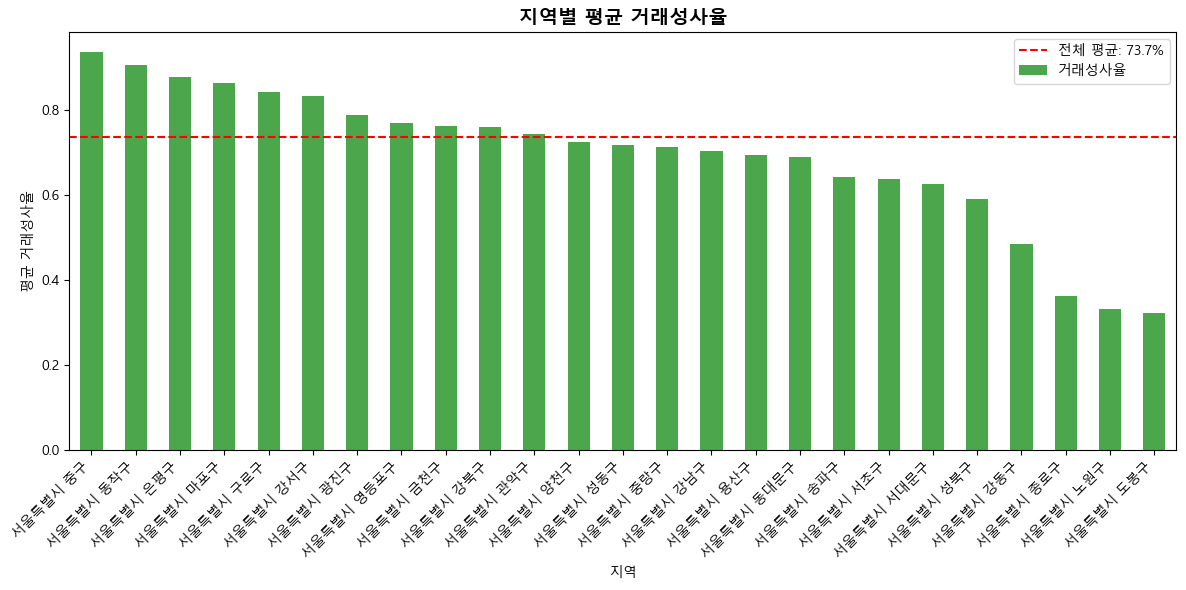

In [11]:
# 3. 시각화 - 지역별 평균 거래성사율
plt.figure(figsize=(12, 6))
region_success = df_eda.groupby('ldCodeNm')['거래성사율'].mean().sort_values(ascending=False)
region_success.plot(kind='bar', color='green', alpha=0.7)
plt.title('지역별 평균 거래성사율', fontsize=14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('평균 거래성사율')
plt.axhline(df_eda['거래성사율'].mean(), color='red', linestyle='--', label=f'전체 평균: {df_eda["거래성사율"].mean():.1%}')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

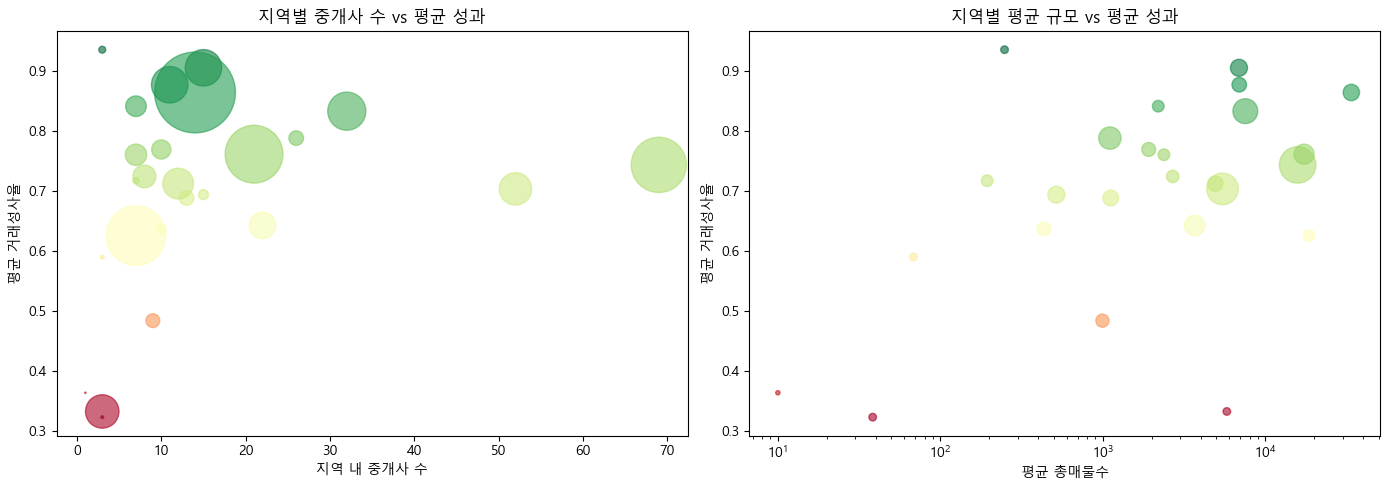

In [12]:
# 4. 지역별 규모 vs 성과
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 중개사 수 vs 평균 성과
region_summary = df_eda.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래성사율': 'mean',
    '총매물수': 'mean'
})
region_summary.columns = ['중개사수', '평균성사율', '평균매물수']

axes[0].scatter(region_summary['중개사수'], region_summary['평균성사율'], 
                s=region_summary['평균매물수']/10, alpha=0.6, c=region_summary['평균성사율'], 
                cmap='RdYlGn')
axes[0].set_xlabel('지역 내 중개사 수')
axes[0].set_ylabel('평균 거래성사율')
axes[0].set_title('지역별 중개사 수 vs 평균 성과')

# 평균 매물수 vs 평균 성과
axes[1].scatter(region_summary['평균매물수'], region_summary['평균성사율'],
                s=region_summary['중개사수']*10, alpha=0.6, c=region_summary['평균성사율'],
                cmap='RdYlGn')
axes[1].set_xlabel('평균 총매물수')
axes[1].set_ylabel('평균 거래성사율')
axes[1].set_title('지역별 평균 규모 vs 평균 성과')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# 데이터 전처리

## 날짜 변환

In [19]:
# 영업기간 계산을 위해
df['registDe'] = pd.to_datetime(df['registDe'])
df['estbsBeginDe'] = pd.to_datetime(df['estbsBeginDe'])
df['estbsEndDe'] = pd.to_datetime(df['estbsEndDe'])

## 결측치 확인

In [20]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

Series([], dtype: int64)


## 중복 데이터 확인

In [21]:
# 중복 확인
duplicates = df.duplicated(subset=['mnnmadr'], keep=False)
duplicate_count = duplicates.sum()

print(f"  - 중복된 데이터: {duplicate_count}개")

if duplicate_count > 0:
    # 중복된 데이터 추출 및 정렬
    duplicate_df = df[duplicates].sort_values('mnnmadr')
    
    print(f"  - 중복 그룹 수: {duplicate_df['mnnmadr'].nunique()}개")

    
    # 전체 중복 데이터 출력
    print("\n중복 데이터 상세:")
    display_cols = ['mnnmadr', 'bsnmCmpnm', 'brkrNm', 'ldCodeNm', '총매물수', '거래완료', '등록매물']
    print(duplicate_df[display_cols])
    
else:
    print("  ✓ 중복 없음")


  - 중복된 데이터: 15개
  - 중복 그룹 수: 7개

중복 데이터 상세:
                  mnnmadr            bsnmCmpnm brkrNm   ldCodeNm   총매물수  \
85   서울특별시 강남구 논현동 269-16         강남하루공인중개사사무소    장정훈  서울특별시 강남구     38   
195  서울특별시 강남구 논현동 269-16           하루공인중개사사무소    정종혁  서울특별시 강남구     53   
24   서울특별시 강남구 역삼동 825-20         엔에이치공인중개사사무소    우남혁  서울특별시 강남구    218   
48   서울특별시 강남구 역삼동 825-20          스카이공인중개사사무소    장진웅  서울특별시 강남구   7431   
303  서울특별시 강남구 역삼동 825-20         갤러리아공인중개사사무소    정준흠  서울특별시 강남구     31   
331     서울특별시 강동구 천호동 571      래미안강동열매공인중개사사무소     양경  서울특별시 강동구      0   
351     서울특별시 강동구 천호동 571           열매공인중개사사무소    김연중  서울특별시 강동구      0   
1    서울특별시 관악구 신림동 476-11        The태양공인중개사사무소    박지애  서울특별시 관악구    995   
110  서울특별시 관악구 신림동 476-11           태양공인중개사사무소    김영민  서울특별시 관악구    485   
6     서울특별시 금천구 가산동 233-5  가산센트럴푸르지오시티공인중개사사무소    오승희  서울특별시 금천구  15800   
268   서울특별시 금천구 가산동 233-5      센트럴푸르지오VIP부동산중개     이진  서울특별시 금천구   3401   
53   서울특별시 동작구 상도동 361-28           또또공인중개사사무소    김대훈  

## 이상치 확인

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"\n{column}:")
    print(f"  Q1 (25%): {Q1:.0f}")
    print(f"  Q3 (75%): {Q3:.0f}")
    print(f"  IQR: {IQR:.0f}")
    print(f"  정상 범위: {lower_bound:.0f} ~ {upper_bound:.0f}")
    print(f"  이상치 개수: {len(outliers)}개 ({len(outliers)/len(data)*100:.1f}%)")
    
    return outliers

outliers_total = detect_outliers_iqr(df, '총매물수')
outliers_complete = detect_outliers_iqr(df, '거래완료')
outliers_registered = detect_outliers_iqr(df, '등록매물')


총매물수:
  Q1 (25%): 48
  Q3 (75%): 2375
  IQR: 2327
  정상 범위: -3443 ~ 5866
  이상치 개수: 59개 (15.5%)

거래완료:
  Q1 (25%): 24
  Q3 (75%): 2310
  IQR: 2286
  정상 범위: -3405 ~ 5739
  이상치 개수: 59개 (15.5%)

등록매물:
  Q1 (25%): 10
  Q3 (75%): 58
  IQR: 48
  정상 범위: -62 ~ 131
  이상치 개수: 39개 (10.3%)


# 파생피처 생성

In [23]:
# 파생피처 전에 df 다시 확인하기

# 원본 데이터
print("="*70)
print("원본 데이터 (df_origin)")
print("="*70)
print(f"Shape: {df_origin.shape[0]}행 x {df_origin.shape[1]}열")
print(f"\nDtype:")
print(df_origin.dtypes)

# EDA용 데이터
print("\n" + "="*70)
print("EDA용 데이터 (df_eda)")
print("="*70)
print(f"Shape: {df_eda.shape[0]}행 x {df_eda.shape[1]}열")
print(f"\nDtype:")
print(df_eda.dtypes)

# 작업용 데이터
print("\n" + "="*70)
print("작업용 데이터 (df)")
print("="*70)
print(f"Shape: {df.shape[0]}행 x {df.shape[1]}열")
print(f"\nDtype:")
print(df.dtypes)


원본 데이터 (df_origin)
Shape: 380행 x 13열

Dtype:
jurirno         object
brkrNm          object
ldCodeNm        object
registDe        object
mnnmadr         object
estbsBeginDe    object
estbsEndDe      object
sttusSeCode      int64
bsnmCmpnm       object
등록번호            object
거래완료             int64
등록매물             int64
총매물수             int64
dtype: object

EDA용 데이터 (df_eda)
Shape: 380행 x 17열

Dtype:
jurirno                 object
brkrNm                  object
ldCodeNm                object
registDe        datetime64[ns]
mnnmadr                 object
estbsBeginDe    datetime64[ns]
estbsEndDe      datetime64[ns]
sttusSeCode              int64
bsnmCmpnm               object
등록번호                    object
거래완료                     int64
등록매물                     int64
총매물수                     int64
success_rate           float64
거래성사율                  float64
보증보험유효                   int64
years_active             int32
dtype: object

작업용 데이터 (df)
Shape: 380행 x 13열

Dtype:
jurirno         

## 영업기간 피쳐

In [26]:
today = pd.to_datetime(datetime.now())

# 영업일수
df['영업일수'] = (today - df['registDe']).dt.days
df['영업일수'] = df['영업일수'].clip(lower=1)

# 영업년수
df['영업년수'] = df['영업일수'] / 365

print(f"영업일수: 평균 {df['영업일수'].mean():.0f}일")
print(f"영업년수: 평균 {df['영업년수'].mean():.1f}년")

영업일수: 평균 2143일
영업년수: 평균 5.9년


## 거래성사율 피쳐

In [29]:
df['거래성사율'] = (df['거래완료'] / df['총매물수'] * 100).fillna(0)
df['거래성사율'] = df['거래성사율'].clip(0, 100)

# 재고율 (등록매물 / 총매물수 * 100)
df['재고율'] = (df['등록매물'] / df['총매물수'] * 100).fillna(0)
df['재고율'] = df['재고율'].clip(0, 100)

거래성사율: 평균 74.2%
재고율: 평균 18.7%
검증 (거래성사율 + 재고율 = 100%): False


## 활동성 기반 피쳐

In [31]:
# 일평균거래
df['일평균거래'] = df['거래완료'] / df['영업일수']

# 월평균거래
df['월평균거래'] = df['일평균거래'] * 30

# 연평균거래
df['연평균거래'] = df['거래완료'] / df['영업년수']

## 지역 기반 피쳐

In [33]:
# 1. 지역별 통계 계산
region_stats = df.groupby('ldCodeNm').agg({
    '거래성사율': 'mean',
    '총매물수': 'count'  # 해당 지역 중개사 수
}).round(2)

region_stats.columns = ['지역평균성사율', '지역별매물수']

# 원본 데이터에 병합
df = df.merge(region_stats, left_on='ldCodeNm', right_index=True, how='left')

# 2. 지역대비 성과 (내 거래성사율 / 지역평균 거래성사율)
df['지역대비성과'] = (df['거래성사율'] / df['지역평균성사율']).fillna(1)

# 결과 출력
print(f"지역평균성사율: 평균 {df['지역평균성사율'].mean():.1f}%")
print(f"지역별매물수: 평균 {df['지역별매물수'].mean():.0f}개")
print(f"지역대비성과: 평균 {df['지역대비성과'].mean():.2f}배")

# 샘플 확인
print("\n샘플 데이터:")
sample_cols = ['brkrNm', 'ldCodeNm', '거래성사율', '지역평균성사율', '지역대비성과', '지역별매물수']
print(df[sample_cols].head(10))

print(f"\n지역 피처 생성 완료: 3개 추가")


지역평균성사율: 평균 74.2%
지역별매물수: 평균 31개
지역대비성과: 평균 1.00배

샘플 데이터:
  brkrNm    ldCodeNm      거래성사율  지역평균성사율    지역대비성과  지역별매물수
0    김대환   서울특별시 관악구  96.197719    74.58  1.289859      69
1    박지애   서울특별시 관악구  95.477387    74.58  1.280201      69
2    김미정   서울특별시 광진구  95.726496    79.17  1.209126      26
3   하임리나   서울특별시 양천구  98.209719    72.62  1.352378       8
4    정종원   서울특별시 관악구  76.744186    74.58  1.029018      69
5    박지연   서울특별시 중랑구  99.781182    71.31  1.399259      12
6    오승희   서울특별시 금천구  99.620253    76.49  1.302396      21
7    최현미   서울특별시 송파구  90.430622    64.88  1.393814      22
8    장대병  서울특별시 동대문구  99.239544    69.25  1.433062      13
9    박승욱   서울특별시 강서구  99.887402    84.00  1.189136      32

지역 피처 생성 완료: 3개 추가


In [35]:
df.head()

,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,거래완료,등록매물,총매물수,영업일수,영업년수,거래성사율,재고율,일평균거래,월평균거래,연평균거래,지역평균성사율,지역별매물수,지역대비성과
0,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,2530,100,2630,1791,4.906849,96.197719,3.802281,1.412619,42.378559,515.605807,74.58,69,1.289859
1,11620-2024-00006,박지애,서울특별시 관악구,2024-01-10,서울특별시 관악구 신림동 476-11,2025-01-12,2026-01-11,1,The태양공인중개사사무소,11620-2024-00006,950,45,995,693,1.898630,95.477387,4.522613,1.370851,41.125541,500.360750,74.58,69,1.280201
2,가3622-05-168,김미정,서울특별시 광진구,2005-10-25,서울특별시 광진구 구의동 254-30,2025-07-22,2026-07-21,1,재테크부동산공인중개사사무소,가3622-05-168,224,10,234,7344,20.120548,95.726496,4.273504,0.030501,0.915033,11.132898,79.17,26,1.209126
3,11470-2022-00111,하임리나,서울특별시 양천구,2022-11-18,서울특별시 양천구 신월동 341-1,2025-11-21,2026-11-20,1,평강부동산공인중개사사무소,11470-2022-00111,1536,28,1564,1111,3.043836,98.209719,1.790281,1.382538,41.476148,504.626463,72.62,8,1.352378
4,11590-2015-00090,정종원,서울특별시 관악구,2015-06-18,서울특별시 관악구 봉천동 893-12,2025-06-18,2026-06-17,1,부동산포커스공인중개사사무소,11590201500090,99,30,129,3821,10.468493,76.744186,23.255814,0.025909,0.777283,9.456948,74.58,69,1.029018


## 조합 피쳐

In [ ]:
# 나중에 추가

# 점수화 (가점, 감점 정의)

In [36]:
# 1. 거래 성사율 점수화

def score_거래성사율(value):
    """
    거래성사율: 높을수록 좋음 (신뢰도 핵심 지표)
    - 90% 이상: 100점 (최우수)
    - 80~90%: 90점 (우수)
    - 70~80%: 80점 (양호)
    - 60~70%: 70점 (보통)
    - 50~60%: 60점 (미흡)
    - 50% 미만: 비례 감점
    """
    if value >= 90:
        return 100
    elif value >= 80:
        return 90
    elif value >= 70:
        return 80
    elif value >= 60:
        return 70
    elif value >= 50:
        return 60
    else:
        return max(0, value)  # 50% 미만은 그대로 점수

In [37]:
# 2. 재고율 점수화
def score_재고율(value):
    """
    재고율: 낮을수록 좋음 (매물이 많이 팔림)
    - 10% 이하: 100점 (매우 빠른 회전)
    - 10~20%: 90점
    - 20~30%: 80점
    - 30~40%: 70점
    - 40~50%: 60점
    - 50~60%: 50점
    - 60% 이상: 급격히 감점
    """
    if value <= 10:
        return 100
    elif value <= 20:
        return 90
    elif value <= 30:
        return 80
    elif value <= 40:
        return 70
    elif value <= 50:
        return 60
    elif value <= 60:
        return 50
    else:
        return max(0, 50 - (value - 60) / 40 * 50)


In [50]:
# # 3.일평균거래 점수화 (0~100점)
# def score_일평균거래(value):
#     """
#     일평균거래: 높을수록 좋음 (활발한 거래)
#     - 10건 이상: 100점 (매우 활발)
#     - 5~10건: 80~100점
#     - 2~5건: 60~80점
#     - 1~2건: 40~60점
#     - 1건 미만: 0~40점
#     """
#     if value >= 10:
#         return 100
#     elif value >= 5:
#         return 80 + (value - 5) / 5 * 20
#     elif value >= 2:
#         return 60 + (value - 2) / 3 * 20
#     elif value >= 1:
#         return 40 + (value - 1) * 20
#     else:
#         return max(0, value * 40)

# 일평균거래 점수화 함수 조정 (기준 완화)
def score_일평균거래(value):
    """기준을 낮춰서 조정"""
    if value >= 5:  # 10 → 5로 완화
        return 100
    elif value >= 3:  # 5 → 3으로 완화
        return 80 + (value - 3) / 2 * 20
    elif value >= 1:
        return 60 + (value - 1) / 2 * 20
    elif value >= 0.5:
        return 40 + (value - 0.5) * 40
    else:
        return max(0, value * 80)


In [51]:
# 총 매물수 점수화
def score_총매물수(value):
    """
    총매물수: 적당히 많을수록 좋음
    - 500~5000: 100점 (적정 범위, 경험 많고 관리 가능)
    - 100~500: 70~100점 (중소형)
    - 5000~10000: 80~100점 (대형)
    - 100 미만: 30~70점 (경험 부족)
    - 10000 이상: 감점 (관리 부실 가능성)
    """
    if 500 <= value <= 5000:
        return 100
    elif 100 <= value < 500:
        return 70 + (value - 100) / 400 * 30
    elif 5000 < value <= 10000:
        return 100 - (value - 5000) / 5000 * 20
    elif value < 100:
        return max(30, value / 100 * 70)
    else:  # 10000 초과
        return max(50, 80 - (value - 10000) / 10000 * 30)

In [52]:
# 영업년수 점수화
def score_영업년수(value):
    """
    영업년수: 많을수록 좋음 (경험 많음)
    - 10년 이상: 100점 (베테랑)
    - 7~10년: 90점
    - 5~7년: 80점
    - 3~5년: 70점
    - 2~3년: 60점
    - 1~2년: 50점
    - 1년 미만: 30~50점
    """
    if value >= 10:
        return 100
    elif value >= 7:
        return 90
    elif value >= 5:
        return 80
    elif value >= 3:
        return 70
    elif value >= 2:
        return 60
    elif value >= 1:
        return 50
    else:
        return max(30, value * 50)

In [ ]:
def score_월평균거래(value):
    """
    월평균거래: 높을수록 좋음
    - 300건 이상: 100점
    - 150~300건: 90점
    - 60~150건: 80점
    - 30~60건: 70점
    - 15~30건: 60점
    - 15건 미만: 비례 감점
    """
    if value >= 300:
        return 100근데
    elif value >= 150:
        return 90
    elif value >= 60:
        return 80
    elif value >= 30:
        return 70
    elif value >= 15:
        return 60
    else:
        return max(0, value / 15 * 60)

# 최종 점수 계산

In [54]:
df['점수_거래성사율'] = df['거래성사율'].apply(score_거래성사율)
df['점수_재고율'] = df['재고율'].apply(score_재고율)
df['점수_일평균거래'] = df['일평균거래'].apply(score_일평균거래)
df['점수_총매물수'] = df['총매물수'].apply(score_총매물수)
df['점수_영업년수'] = df['영업년수'].apply(score_영업년수)
df['점수_월평균거래'] = df['월평균거래'].apply(score_월평균거래)

print("✓ 점수 계산 완료")

✓ 점수 계산 완료


In [55]:
# 점수 기본 통계
print("\n점수 기본 통계:")
score_cols = ['점수_거래성사율', '점수_재고율', '점수_일평균거래', '점수_총매물수', 
              '점수_영업년수', '점수_월평균거래']
print(df[score_cols].describe().round(1))


점수 기본 통계:
       점수_거래성사율  점수_재고율  점수_일평균거래  점수_총매물수  점수_영업년수  점수_월평균거래
count     380.0   380.0     380.0    380.0    380.0     380.0
mean       76.9    84.5      37.8     68.5     69.0      40.3
std        36.4    29.1      39.4     28.7     22.2      37.9
min         0.0     0.0       0.0     30.0     30.0       0.0
25%        70.0    90.0       1.3     33.2     50.0       1.9
50%       100.0   100.0      20.6     75.2     70.0      30.9
75%       100.0   100.0      72.9    100.0     90.0      80.0
max       100.0   100.0     100.0    100.0    100.0     100.0


In [56]:
# 샘플 확인 (원본 값 vs 점수)
print("\n샘플 데이터 (원본 vs 점수):")
sample_cols = ['brkrNm', 
               '거래성사율', '점수_거래성사율',
               '재고율', '점수_재고율',
               '일평균거래', '점수_일평균거래',
               '총매물수', '점수_총매물수']
print(df[sample_cols].head(10))


샘플 데이터 (원본 vs 점수):
  brkrNm      거래성사율  점수_거래성사율        재고율  점수_재고율      일평균거래    점수_일평균거래  \
0    김대환  96.197719     100.0   3.802281   100.0   1.412619   64.126186   
1    박지애  95.477387     100.0   4.522613   100.0   1.370851   63.708514   
2    김미정  95.726496     100.0   4.273504   100.0   0.030501    2.440087   
3   하임리나  98.209719     100.0   1.790281   100.0   1.382538   63.825383   
4    정종원  76.744186      80.0  23.255814    80.0   0.025909    2.072756   
5    박지연  99.781182     100.0   0.218818   100.0   0.440519   35.241513   
6    오승희  99.620253     100.0   0.379747   100.0   3.257450   82.574503   
7    최현미  90.430622     100.0   9.569378   100.0   0.076705    6.136364   
8    장대병  99.239544     100.0   0.760456   100.0  10.348018  100.000000   
9    박승욱  99.887402     100.0   0.112598   100.0  37.514925  100.000000   

    총매물수  점수_총매물수  
0   2630  100.000  
1    995  100.000  
2    234   80.050  
3   1564  100.000  
4    129   72.175  
5   3199  100.000  
6  15800   62.

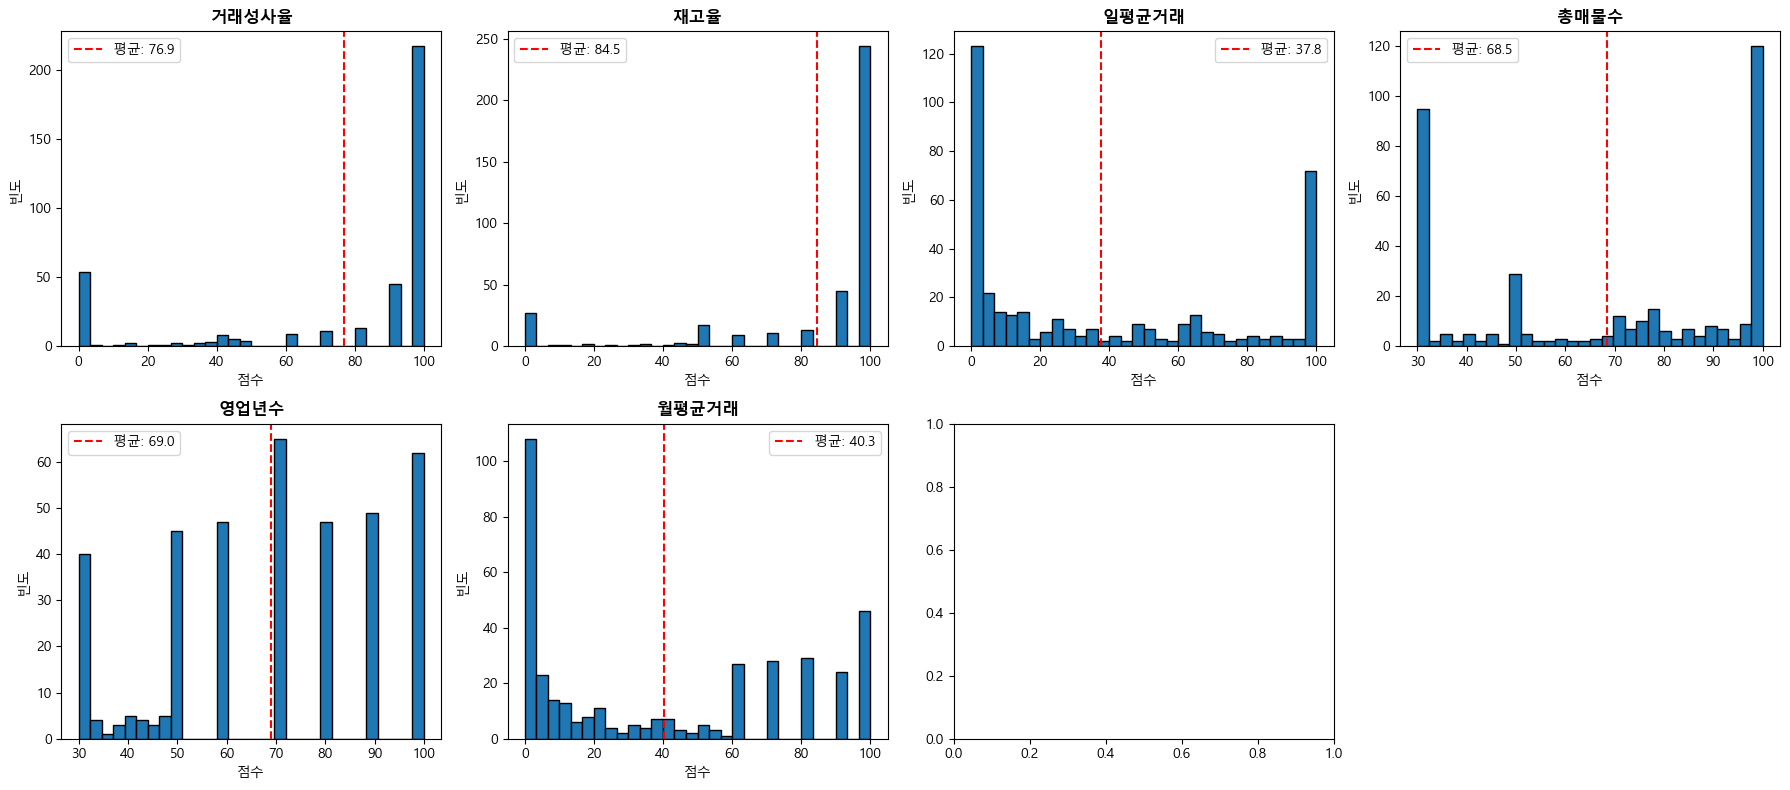

In [57]:
# 점수 분포 시각화
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(score_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black')
    axes[idx].set_title(col.replace('점수_', ''), fontweight='bold')
    axes[idx].set_xlabel('점수')
    axes[idx].set_ylabel('빈도')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                     label=f'평균: {df[col].mean():.1f}')
    axes[idx].legend()

# 마지막 subplot 제거
axes[-1].remove()

plt.tight_layout()
plt.show()

STEP 8: 최종 점수 계산 (가중치 적용)

가중치 합계: 1.00

가중치 설정:
  거래성사율: 30%
  재고율: 25%
  총매물수: 15%
  영업년수: 10%
  일평균거래: 10%
  월평균거래: 10%

✓ 최종 점수 계산 완료

최종 점수 통계:
count    380.00
mean      69.17
std       25.50
min        7.50
25%       49.53
50%       80.04
75%       89.50
max       95.11
Name: 최종점수, dtype: float64


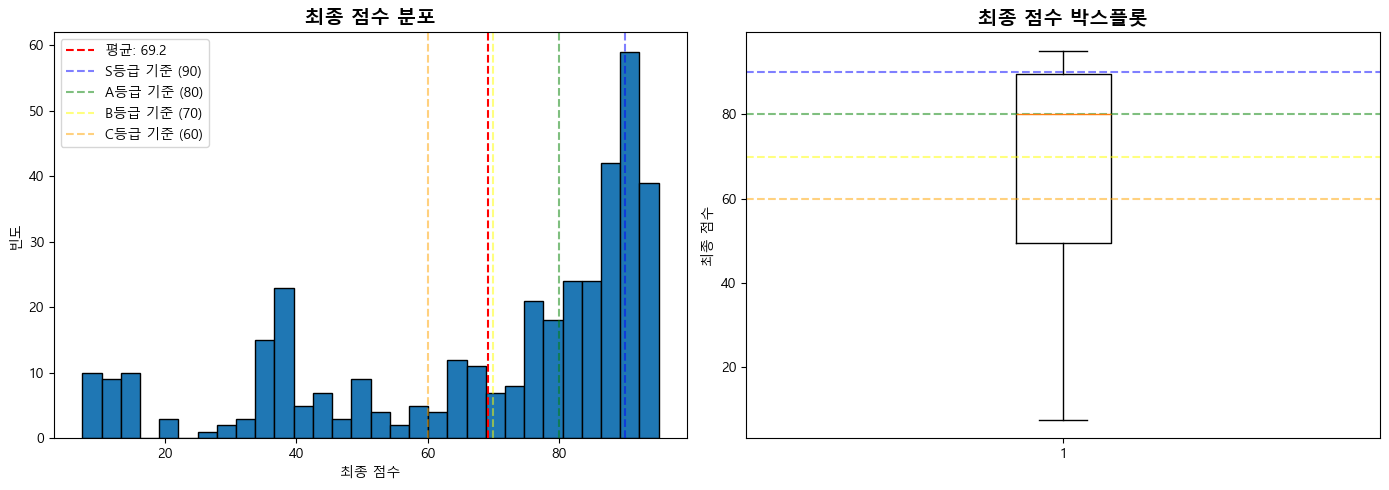


상위 10개 중개사:
    brkrNm        bsnmCmpnm    ldCodeNm       최종점수      거래성사율       재고율  \
66     김형준      플렉스공인중개사사무소   서울특별시 동작구  95.109000  99.275251  0.724749   
8      장대병    국민부동산공인중개사사무소  서울특별시 동대문구  95.000000  99.239544  0.760456   
237    임성훈    판다부동산공인중개사사무소   서울특별시 관악구  94.863014  97.655678  2.344322   
209    김순오       이안공인중개사사무소   서울특별시 구로구  94.596200  99.277278  0.722722   
184    방현철  부동산이즈똑똑공인중개사사무소   서울특별시 은평구  94.000000  98.272553  1.727447   
191    박준규       청년공인중개사사무소  서울특별시 서대문구  94.000000  97.269625  2.730375   
227    고동한     집토스부동산중개강서본점   서울특별시 강서구  94.000000  99.168918  0.831082   
248    조승우    집토스부동산중개강남2호점   서울특별시 강남구  94.000000  99.044521  0.955479   
374    박성현      한마음공인중개사사무소   서울특별시 관악구  94.000000  97.522575  2.477425   
168    이원영    인앤하우스공인중개사사무소   서울특별시 강동구  93.903800  99.399443  0.600557   

         일평균거래  총매물수  
66    5.642419  6485  
8    10.348018  4734  
237  11.264789  4095  
209  10.686907  5673  
184   8.393443  3647  
191   7.721675  3223  


In [61]:
# ============================================================================
# STEP 8: 가중치 적용하여 최종 점수 계산
# ============================================================================
print("="*70)
print("STEP 8: 최종 점수 계산 (가중치 적용)")
print("="*70)

# 가중치 정의
weights = {
    '거래성사율': 0.30,      # 가장 중요 (신뢰도 핵심)
    '재고율': 0.25,          # 두번째로 중요 (매물 회전율)
    '총매물수': 0.15,        # 세번째 (경험/규모)
    '영업년수': 0.10,        # 네번째 (경력)
    '일평균거래': 0.10,      # 다섯번째 (활동성)
    '월평균거래': 0.10       # 여섯번째 (활동성 보조)
}

# 가중치 합계 확인
total_weight = sum(weights.values())
print(f"\n가중치 합계: {total_weight:.2f}")
assert abs(total_weight - 1.0) < 0.01, "가중치 합계가 1이 아닙니다!"

# 가중치 출력
print("\n가중치 설정:")
for feature, weight in weights.items():
    print(f"  {feature}: {weight*100:.0f}%")

# 최종 점수 계산
df['최종점수'] = (
    df['점수_거래성사율'] * weights['거래성사율'] +
    df['점수_재고율'] * weights['재고율'] +
    df['점수_총매물수'] * weights['총매물수'] +
    df['점수_영업년수'] * weights['영업년수'] +
    df['점수_일평균거래'] * weights['일평균거래'] +
    df['점수_월평균거래'] * weights['월평균거래']
)

print("\n✓ 최종 점수 계산 완료")

# 최종 점수 통계
print("\n최종 점수 통계:")
print(df['최종점수'].describe().round(2))

# 최종 점수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df['최종점수'], bins=30, edgecolor='black')
axes[0].axvline(df['최종점수'].mean(), color='red', linestyle='--', 
               label=f'평균: {df["최종점수"].mean():.1f}')
axes[0].axvline(90, color='blue', linestyle='--', alpha=0.5, label='S등급 기준 (90)')
axes[0].axvline(80, color='green', linestyle='--', alpha=0.5, label='A등급 기준 (80)')
axes[0].axvline(70, color='yellow', linestyle='--', alpha=0.5, label='B등급 기준 (70)')
axes[0].axvline(60, color='orange', linestyle='--', alpha=0.5, label='C등급 기준 (60)')
axes[0].set_title('최종 점수 분포', fontweight='bold', fontsize=14)
axes[0].set_xlabel('최종 점수')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 박스플롯
axes[1].boxplot(df['최종점수'])
axes[1].set_title('최종 점수 박스플롯', fontweight='bold', fontsize=14)
axes[1].set_ylabel('최종 점수')
axes[1].axhline(90, color='blue', linestyle='--', alpha=0.5)
axes[1].axhline(80, color='green', linestyle='--', alpha=0.5)
axes[1].axhline(70, color='yellow', linestyle='--', alpha=0.5)
axes[1].axhline(60, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 상위/하위 중개사 확인
print("\n상위 10개 중개사:")
top10 = df.nlargest(10, '최종점수')[['brkrNm', 'bsnmCmpnm', 'ldCodeNm', '최종점수', 
                                      '거래성사율', '재고율', '일평균거래', '총매물수']]
print(top10)

print("\n하위 10개 중개사:")
bottom10 = df.nsmallest(10, '최종점수')[['brkrNm', 'bsnmCmpnm', 'ldCodeNm', '최종점수', 
                                         '거래성사율', '재고율', '일평균거래', '총매물수']]
print(bottom10)

# 각 점수 피처의 기여도 확인
print("\n각 피처의 평균 기여도 (최종 점수에 미치는 영향):")
for feature, weight in weights.items():
    contribution = df[f'점수_{feature}'].mean() * weight
    print(f"  {feature}: {contribution:.2f}점 (가중치 {weight*100:.0f}%)")

print("\n" + "="*70)
print("다음 단계: 등급 분류")
print("="*70)


# 등급분류(다중 분류)

STEP 9: 등급 분류 (백분위 기반)
✓ 등급 분류 완료 (백분위 기반)

등급별 분포:
  D등급:  76개 ( 20.0%)
  C등급:  76개 ( 20.0%)
  B등급:  76개 ( 20.0%)
  A등급:  80개 ( 21.1%)
  S등급:  72개 ( 18.9%)

등급별 점수 범위:
       최소     최대     평균
등급                     
D    7.50  39.50  26.15
C   39.90  74.57  59.12
B   74.63  84.90  80.02
A   85.50  90.50  88.25
S   90.65  95.11  92.54

등급별 평균 특성:
     최종점수  거래성사율    재고율  일평균거래      총매물수  영업년수
등급                                            
D   26.15   9.56  54.91   0.02     18.80  4.79
C   59.12  71.94  28.06   0.10     98.54  7.59
B   80.02  93.55   6.45   0.33    482.11  8.39
A   88.25  97.69   2.31  66.04  31325.34  4.53
S   92.54  98.06   1.94  10.94   7064.10  4.03


C:\Users\Playdata\AppData\Local\Temp\ipykernel_12168\714105150.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_ranges = df.groupby('등급')['최종점수'].agg(['min', 'max', 'mean']).round(2)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_12168\714105150.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_features = df.groupby('등급').agg({


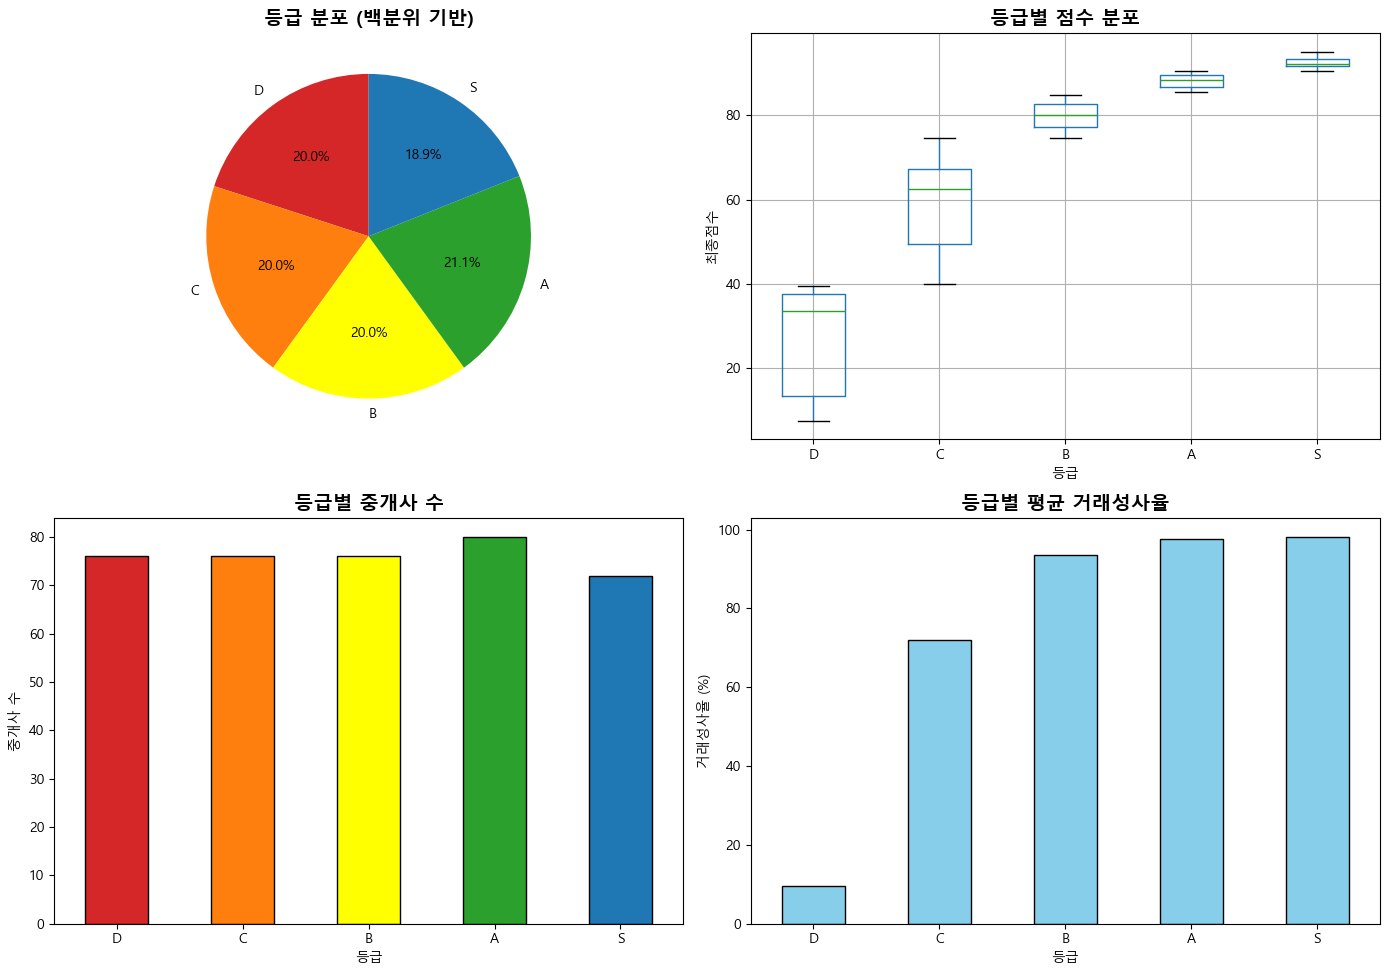


등급별 대표 중개사 (각 등급 상위 3개)

S등급:
  - 김형준 (플렉스공인중개사사무소, 서울특별시 동작구)
    최종점수: 95.1점
    거래성사율: 99.3% | 재고율: 0.7% | 일평균거래: 5.64건
  - 장대병 (국민부동산공인중개사사무소, 서울특별시 동대문구)
    최종점수: 95.0점
    거래성사율: 99.2% | 재고율: 0.8% | 일평균거래: 10.35건
  - 임성훈 (판다부동산공인중개사사무소, 서울특별시 관악구)
    최종점수: 94.9점
    거래성사율: 97.7% | 재고율: 2.3% | 일평균거래: 11.26건

A등급:
  - 채희원 (감자공인중개사사무소, 서울특별시 중랑구)
    최종점수: 90.5점
    거래성사율: 99.8% | 재고율: 0.2% | 일평균거래: 7.18건
  - 유미선 (119부동산공인중개사사무소, 서울특별시 관악구)
    최종점수: 90.5점
    거래성사율: 99.9% | 재고율: 0.1% | 일평균거래: 40.25건
  - 김동혁 (주식회사피터팬의좋은방구하기부동산중개법인, 서울특별시 금천구)
    최종점수: 90.5점
    거래성사율: 99.9% | 재고율: 0.1% | 일평균거래: 145.82건

B등급:
  - 권지혜 (백억공인중개사사무소, 서울특별시 강서구)
    최종점수: 84.9점
    거래성사율: 96.8% | 재고율: 3.2% | 일평균거래: 0.35건
  - 이동형 (래미안공인중개사사무소, 서울특별시 용산구)
    최종점수: 84.9점
    거래성사율: 98.4% | 재고율: 1.6% | 일평균거래: 0.29건
  - 이연옥 (이화공인중개사사무소, 서울특별시 광진구)
    최종점수: 84.7점
    거래성사율: 99.0% | 재고율: 1.0% | 일평균거래: 0.23건

C등급:
  - 김철호 (금빛부동산공인중개사사무소, 서울특별시 광진구)
    최종점수: 74.6점
    거래성사율: 91.9% | 재고율: 8.1% | 일평균거래: 0.05건

In [64]:
# ============================================================================
# STEP 9: 등급 분류 (백분위 기반 균등 분포)
# ============================================================================
print("="*70)
print("STEP 9: 등급 분류 (백분위 기반)")
print("="*70)

# 백분위 기반 등급 분류 (각 등급이 20%씩 균등 분포)
df['등급'] = pd.qcut(df['최종점수'], 
                     q=5, 
                     labels=['D', 'C', 'B', 'A', 'S'],
                     duplicates='drop')

print("✓ 등급 분류 완료 (백분위 기반)")

# 등급별 분포
print("\n등급별 분포:")
grade_dist = df['등급'].value_counts().sort_index()
for grade, count in grade_dist.items():
    pct = count / len(df) * 100
    print(f"  {grade}등급: {count:3d}개 ({pct:5.1f}%)")

# 등급별 점수 범위
print("\n등급별 점수 범위:")
grade_ranges = df.groupby('등급')['최종점수'].agg(['min', 'max', 'mean']).round(2)
grade_ranges.columns = ['최소', '최대', '평균']
print(grade_ranges)

# 등급별 특성 비교
print("\n등급별 평균 특성:")
grade_features = df.groupby('등급').agg({
    '최종점수': 'mean',
    '거래성사율': 'mean',
    '재고율': 'mean',
    '일평균거래': 'mean',
    '총매물수': 'mean',
    '영업년수': 'mean'
}).round(2)
print(grade_features)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 등급 분포 파이 차트
colors = ['#d62728', '#ff7f0e', '#ffff00', '#2ca02c', '#1f77b4']
grade_counts = df['등급'].value_counts().sort_index()
axes[0, 0].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 0].set_title('등급 분포 (백분위 기반)', fontweight='bold', fontsize=14)

# 2. 등급별 점수 박스플롯
df.boxplot(column='최종점수', by='등급', ax=axes[0, 1])
axes[0, 1].set_title('등급별 점수 분포', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('등급')
axes[0, 1].set_ylabel('최종점수')
axes[0, 1].get_figure().suptitle('')

# 3. 등급별 중개사 수
grade_counts.plot(kind='bar', ax=axes[1, 0], color=colors, edgecolor='black')
axes[1, 0].set_title('등급별 중개사 수', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('등급')
axes[1, 0].set_ylabel('중개사 수')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# 4. 등급별 평균 거래성사율
grade_features['거래성사율'].plot(kind='bar', ax=axes[1, 1], color='skyblue', edgecolor='black')
axes[1, 1].set_title('등급별 평균 거래성사율', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('등급')
axes[1, 1].set_ylabel('거래성사율 (%)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# 등급별 대표 중개사
print("\n" + "="*70)
print("등급별 대표 중개사 (각 등급 상위 3개)")
print("="*70)

for grade in ['S', 'A', 'B', 'C', 'D']:
    grade_df = df[df['등급'] == grade].nlargest(3, '최종점수')
    if len(grade_df) > 0:
        print(f"\n{grade}등급:")
        for idx, row in grade_df.iterrows():
            print(f"  - {row['brkrNm']} ({row['bsnmCmpnm']}, {row['ldCodeNm']})")
            print(f"    최종점수: {row['최종점수']:.1f}점")
            print(f"    거래성사율: {row['거래성사율']:.1f}% | 재고율: {row['재고율']:.1f}% | 일평균거래: {row['일평균거래']:.2f}건")

print("\n" + "="*70)
print("등급 분류 완료!")
print("="*70)
print(f"총 {len(df)}개 중개사 등급 분류 완료")
print("\n다음 단계: ML 모델 학습 (선택사항)")


# ML 학습

## 학습에 사용할 피쳐

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# 학습에 사용할 피처 선택
feature_columns = [
    '거래성사율',          # 핵심
    '재고율',              # 핵심
    '일평균거래',          # 활동성
    '총매물수',            # 규모
    '영업년수',            # 경력
    '지역평균성사율',      # 지역 정보
    '지역대비성과'         # 지역 내 상대 성과
]

X = df[feature_columns]
y = df['등급']

print(f"피처: {feature_columns}")
print(f"타겟: 등급 (S/A/B/C/D)")
print(f"데이터 크기: {X.shape}")

# 학습/테스트 데이터 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

피처: ['거래성사율', '재고율', '일평균거래', '총매물수', '영업년수', '지역평균성사율', '지역대비성과']
타겟: 등급 (S/A/B/C/D)
데이터 크기: (380, 7)


## RandomForest

In [77]:
# RandomForest 모델 생성
model = RandomForestClassifier(
    n_estimators=100,      # 트리 개수
    max_depth=10,          # 최대 깊이
    min_samples_split=5,   # 분할 최소 샘플 수
    min_samples_leaf=2,    # 리프 노드 최소 샘플 수
    random_state=42,
    n_jobs=-1              # 모든 CPU 사용
)

print("모델 학습 중...")
model.fit(X_train, y_train)
print("✓ 모델 학습 완료")

모델 학습 중...
✓ 모델 학습 완료


# Test 성능평가


정확도: 0.868 (86.8%)

분류 리포트:
              precision    recall  f1-score   support

           D       0.78      0.88      0.82        16
           C       0.93      0.87      0.90        15
           B       0.82      0.93      0.88        15
           A       0.93      0.93      0.93        15
           S       0.92      0.73      0.81        15

    accuracy                           0.87        76
   macro avg       0.88      0.87      0.87        76
weighted avg       0.87      0.87      0.87        76


Confusion Matrix:
[[14  1  0  0  0]
 [ 1 14  0  0  0]
 [ 0  2 13  0  0]
 [ 0  0  1 14  1]
 [ 0  0  0  4 11]]


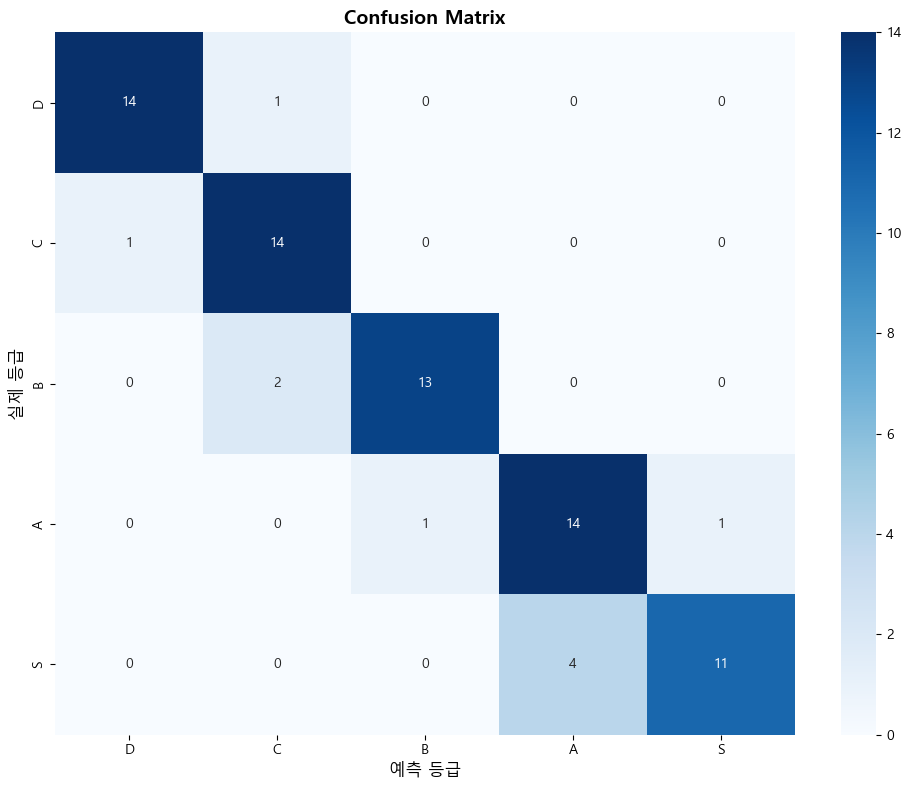

In [78]:
# 예측
y_pred = model.predict(X_test)

# 정확도
accuracy = accuracy_score(y_test, y_pred)
print(f"\n정확도: {accuracy:.3f} ({accuracy*100:.1f}%)")

# 분류 리포트
print("\n분류 리포트:")
print(classification_report(y_test, y_pred, target_names=['D', 'C', 'B', 'A', 'S']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred, labels=['D', 'C', 'B', 'A', 'S'])
print(cm)

# Confusion Matrix 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['D', 'C', 'B', 'A', 'S'],
            yticklabels=['D', 'C', 'B', 'A', 'S'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('실제 등급', fontsize=12)
plt.xlabel('예측 등급', fontsize=12)
plt.tight_layout()
plt.show()

# 피처 중요도

SHAP 피처 중요도 분석
✓ SHAP 라이브러리 로드 완료

SHAP Explainer 생성 중...
✓ SHAP values 계산 완료
SHAP values shape: (76, 7, 5)
클래스 개수: 5
각 클래스 SHAP shape: (76, 7)

[1] 평균 절대 SHAP 중요도

SHAP 기반 피처 중요도:
        피처  SHAP 중요도
3     총매물수  0.080476
2    일평균거래  0.070148
0    거래성사율  0.066987
1      재고율  0.047272
6   지역대비성과  0.038784
4     영업년수  0.009513
5  지역평균성사율  0.003538


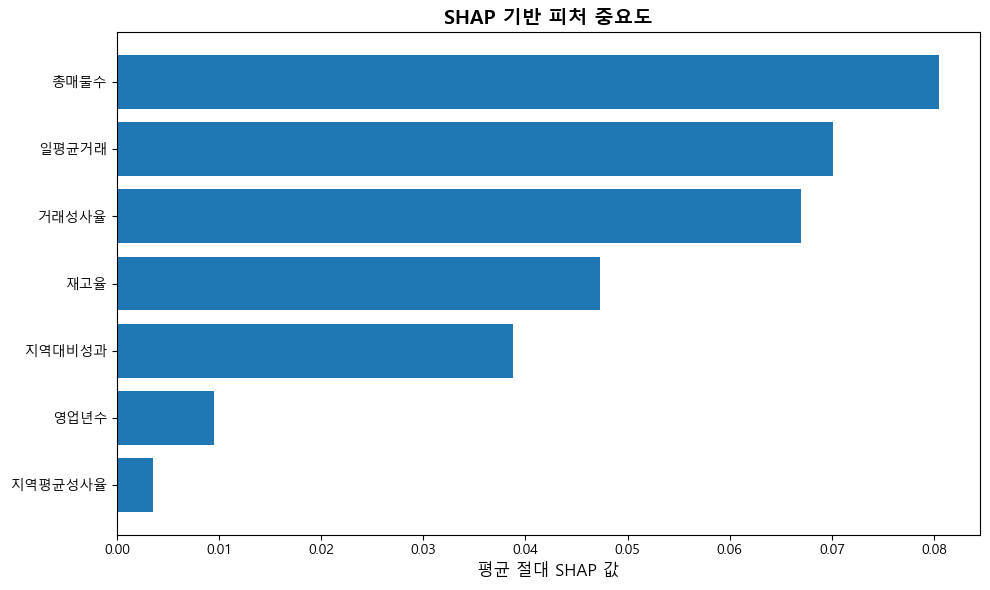


[2] 등급별 SHAP Summary Plot

D등급 SHAP Summary Plot


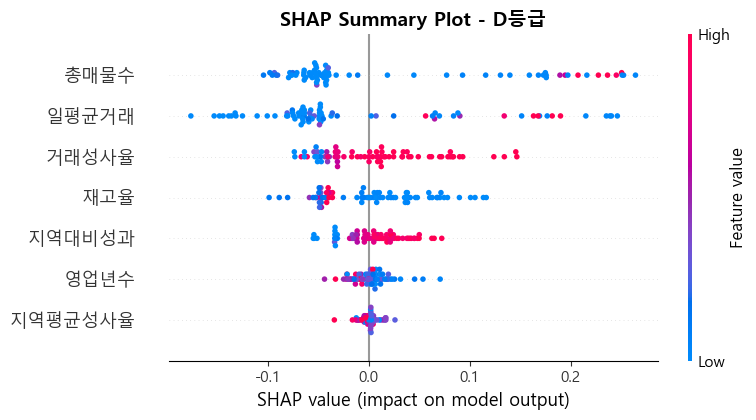


C등급 SHAP Summary Plot


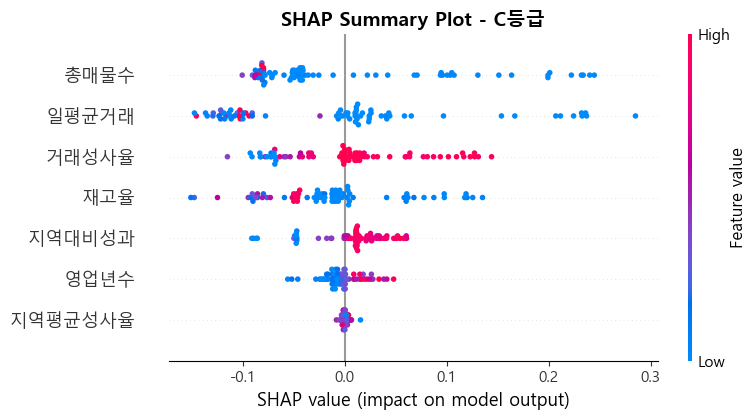


B등급 SHAP Summary Plot


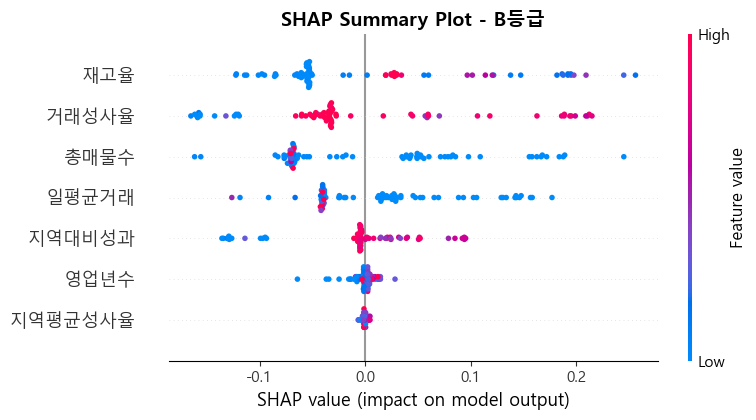


A등급 SHAP Summary Plot


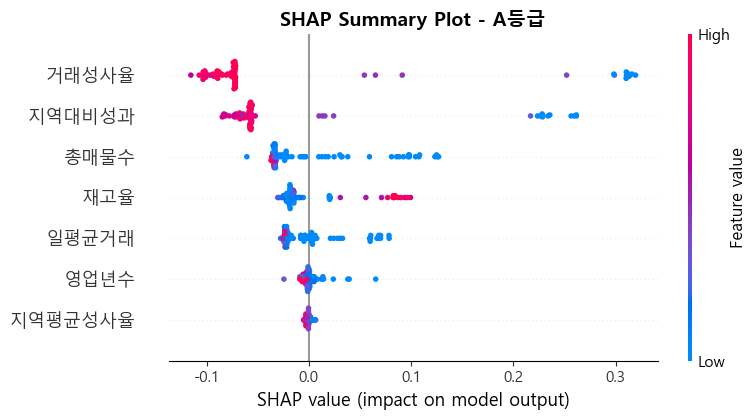


S등급 SHAP Summary Plot


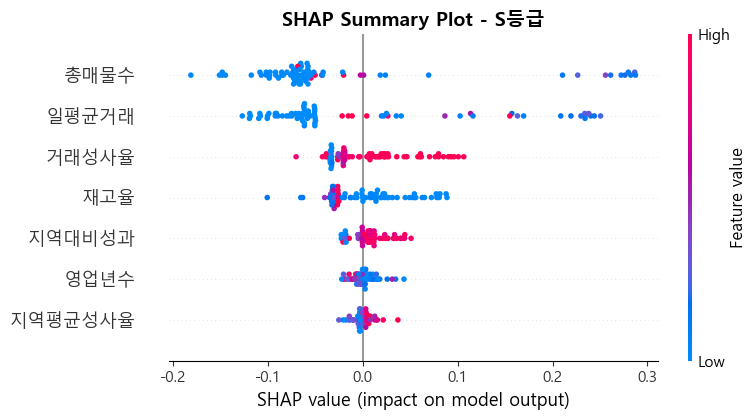


[3] 전체 평균 SHAP Summary Plot


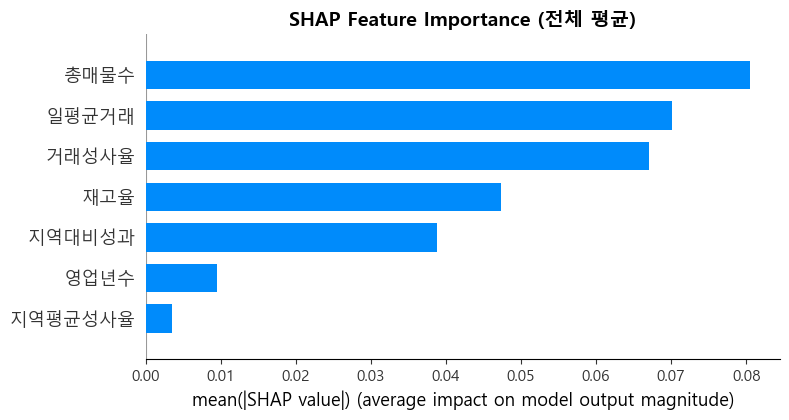


[4] SHAP vs Feature Importance 비교

SHAP vs RandomForest 중요도 비교:
        피처    SHAP      RF
0     총매물수  0.0805  0.2527
1    일평균거래  0.0701  0.2064
2    거래성사율  0.0670  0.2113
3      재고율  0.0473  0.1449
4   지역대비성과  0.0388  0.1241
5     영업년수  0.0095  0.0446
6  지역평균성사율  0.0035  0.0160


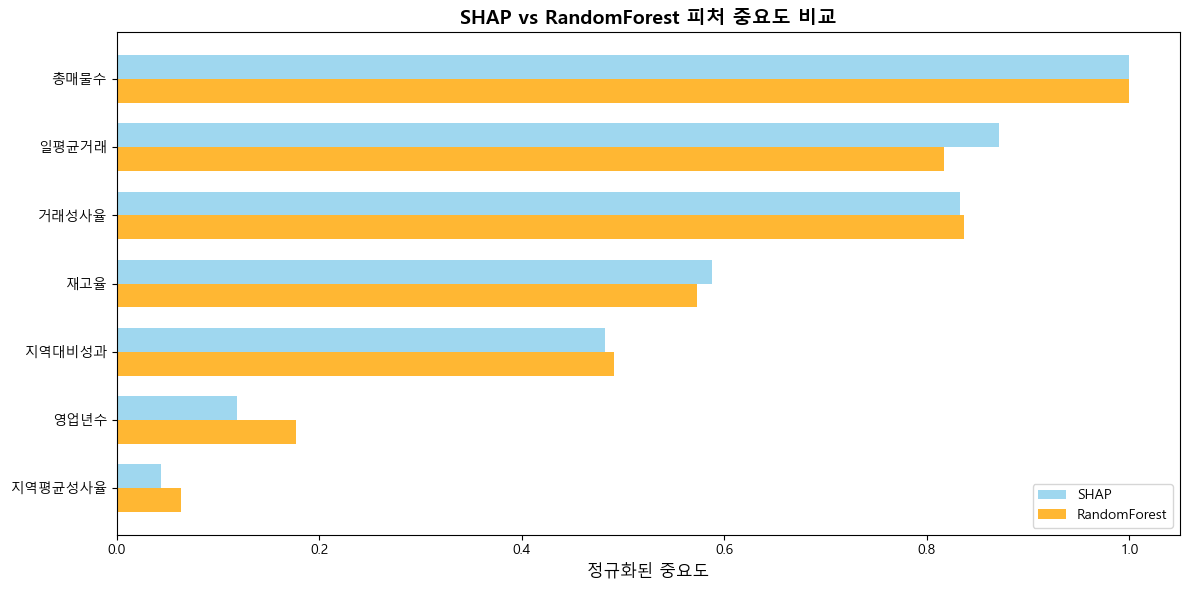


[5] 등급별 평균 SHAP 중요도

등급별 SHAP 중요도:
              D       C       B       A       S
거래성사율    0.0442  0.0496  0.0827  0.1238  0.0347
재고율      0.0422  0.0484  0.0841  0.0292  0.0325
일평균거래    0.0932  0.0834  0.0566  0.0228  0.0947
총매물수     0.0963  0.0838  0.0801  0.0440  0.0982
영업년수     0.0130  0.0138  0.0069  0.0056  0.0083
지역평균성사율  0.0058  0.0022  0.0017  0.0019  0.0061
지역대비성과   0.0229  0.0291  0.0361  0.0910  0.0149


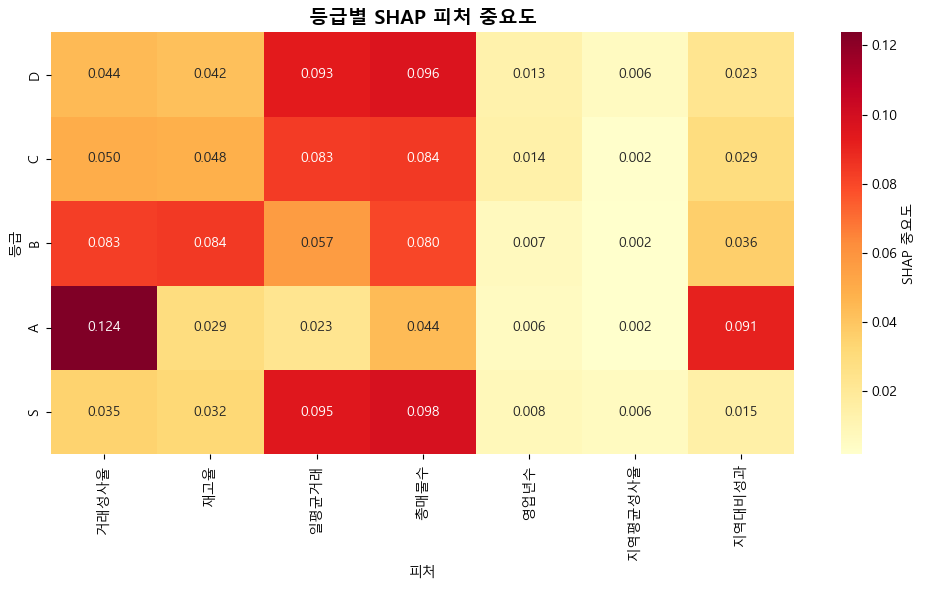


SHAP 분석 완료!


In [79]:
# ============================================================================
# SHAP을 이용한 피처 중요도 분석 (수정 v2)
# ============================================================================
print("="*70)
print("SHAP 피처 중요도 분석")
print("="*70)

# SHAP 설치 확인 및 import
try:
    import shap
    print("✓ SHAP 라이브러리 로드 완료")
except ImportError:
    print("SHAP 설치 중...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
    print("✓ SHAP 설치 및 로드 완료")

# ----------------------------------------------------------------------------
# SHAP Explainer 생성
# ----------------------------------------------------------------------------
print("\nSHAP Explainer 생성 중...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✓ SHAP values 계산 완료")
print(f"SHAP values shape: {np.array(shap_values).shape}")

# SHAP values를 리스트로 변환 (각 클래스별)
# shape: (n_samples, n_features, n_classes) → 리스트로 분리
if isinstance(shap_values, list):
    # 이미 리스트 형태 (클래스별로 분리됨)
    shap_list = shap_values
else:
    # numpy 배열이면 클래스별로 분리
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f"클래스 개수: {len(shap_list)}")
print(f"각 클래스 SHAP shape: {shap_list[0].shape}")

# ----------------------------------------------------------------------------
# 1. 평균 절대 SHAP 중요도
# ----------------------------------------------------------------------------
print("\n[1] 평균 절대 SHAP 중요도")

# 모든 클래스의 SHAP values를 합쳐서 평균 계산
all_shap = np.concatenate([np.abs(shap) for shap in shap_list], axis=0)
mean_abs_shap = all_shap.mean(axis=0)

shap_importance = pd.DataFrame({
    '피처': feature_columns,
    'SHAP 중요도': mean_abs_shap
}).sort_values('SHAP 중요도', ascending=False)

print("\nSHAP 기반 피처 중요도:")
print(shap_importance)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(shap_importance['피처'], shap_importance['SHAP 중요도'])
plt.xlabel('평균 절대 SHAP 값', fontsize=12)
plt.title('SHAP 기반 피처 중요도', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 2. 등급별 SHAP Summary Plot
# ----------------------------------------------------------------------------
print("\n[2] 등급별 SHAP Summary Plot")

grade_names = ['D', 'C', 'B', 'A', 'S']

for idx, grade in enumerate(grade_names):
    print(f"\n{grade}등급 SHAP Summary Plot")
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_list[idx],
        X_test,
        feature_names=feature_columns,
        show=False
    )
    plt.title(f'SHAP Summary Plot - {grade}등급', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 3. 전체 평균 SHAP Summary Plot (Bar)
# ----------------------------------------------------------------------------
print("\n[3] 전체 평균 SHAP Summary Plot")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    all_shap,
    np.tile(X_test.values, (len(shap_list), 1)),
    feature_names=feature_columns,
    plot_type="bar",
    show=False
)
plt.title('SHAP Feature Importance (전체 평균)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 4. SHAP vs Feature Importance 비교
# ----------------------------------------------------------------------------
print("\n[4] SHAP vs Feature Importance 비교")

rf_importance = pd.DataFrame({
    '피처': feature_columns,
    'RF 중요도': model.feature_importances_
}).sort_values('RF 중요도', ascending=False)

comparison = pd.merge(
    shap_importance.rename(columns={'SHAP 중요도': 'SHAP'}),
    rf_importance.rename(columns={'RF 중요도': 'RF'}),
    on='피처'
)

comparison['SHAP_norm'] = comparison['SHAP'] / comparison['SHAP'].max()
comparison['RF_norm'] = comparison['RF'] / comparison['RF'].max()

print("\nSHAP vs RandomForest 중요도 비교:")
print(comparison[['피처', 'SHAP', 'RF']].round(4))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35

ax.barh(x - width/2, comparison['SHAP_norm'], width, label='SHAP', alpha=0.8, color='skyblue')
ax.barh(x + width/2, comparison['RF_norm'], width, label='RandomForest', alpha=0.8, color='orange')

ax.set_yticks(x)
ax.set_yticklabels(comparison['피처'])
ax.set_xlabel('정규화된 중요도', fontsize=12)
ax.set_title('SHAP vs RandomForest 피처 중요도 비교', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. 등급별 평균 SHAP 중요도
# ----------------------------------------------------------------------------
print("\n[5] 등급별 평균 SHAP 중요도")

grade_shap_importance = {}
for idx, grade in enumerate(grade_names):
    grade_mean = np.abs(shap_list[idx]).mean(axis=0)
    grade_shap_importance[grade] = grade_mean

grade_shap_df = pd.DataFrame(grade_shap_importance, index=feature_columns)
print("\n등급별 SHAP 중요도:")
print(grade_shap_df.round(4))

# 히트맵으로 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(grade_shap_df.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'SHAP 중요도'})
plt.title('등급별 SHAP 피처 중요도', fontsize=14, fontweight='bold')
plt.xlabel('피처')
plt.ylabel('등급')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SHAP 분석 완료!")
print("="*70)
